In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


In [4]:
# Load dataset
df = pd.read_csv("diabetes (1).csv")

print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


#### Exploratory Data Analysis

In [5]:
# Check Missing values and dataset Information
print(df.info())
print("\nMissing Values:\n")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age    

In [6]:
# Statistical Summary
print(df.describe())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

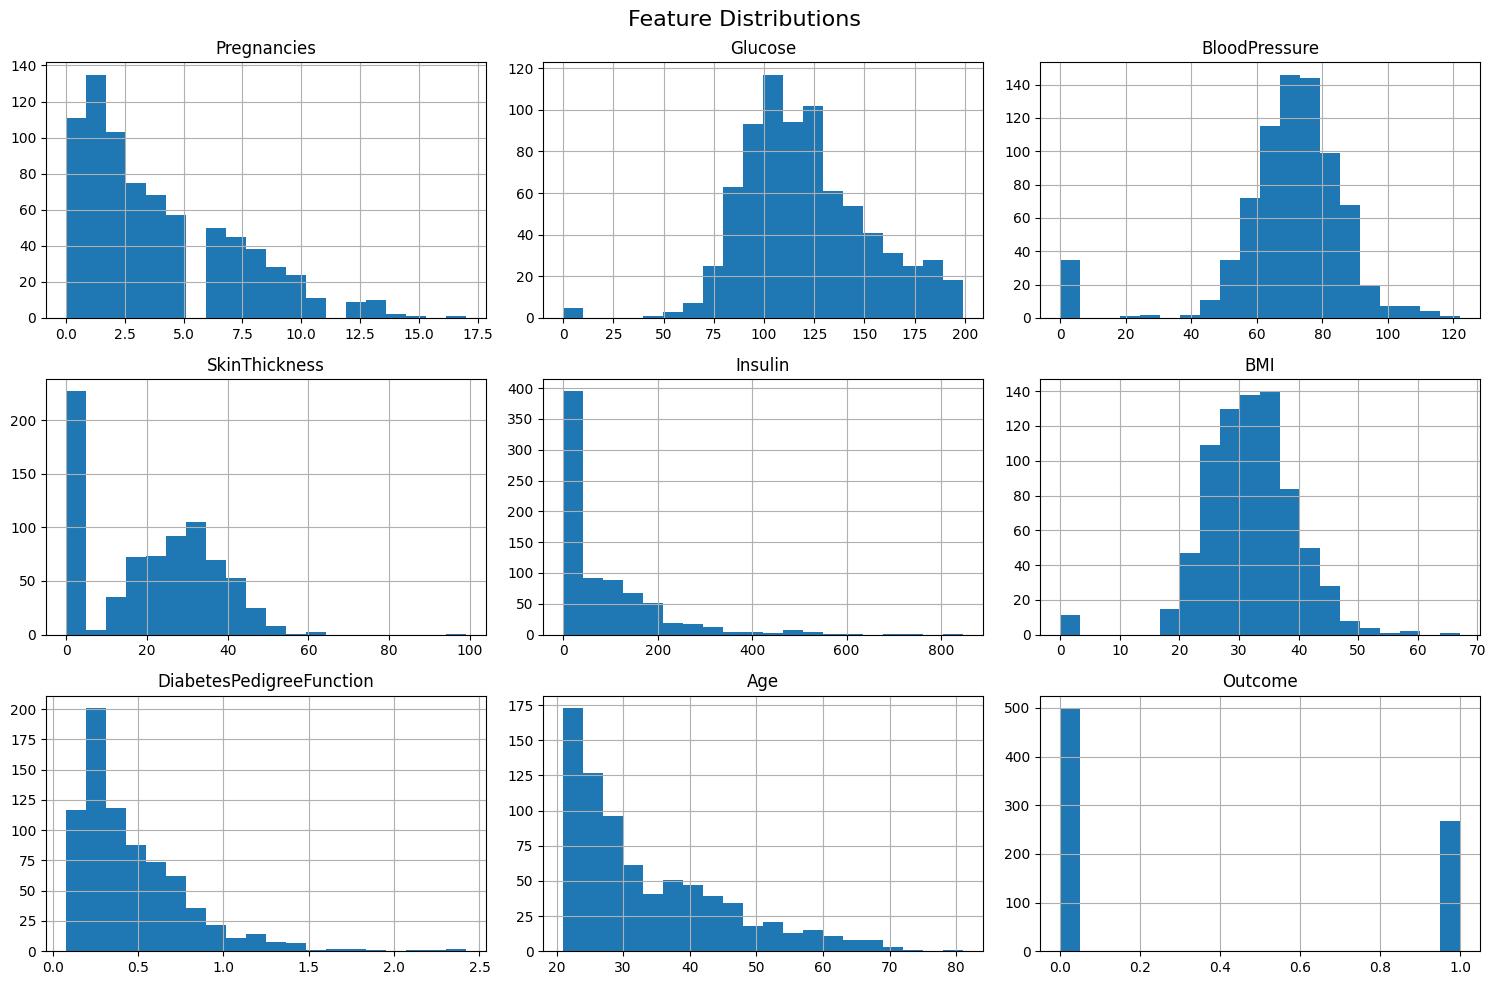

In [7]:
# Histograms
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


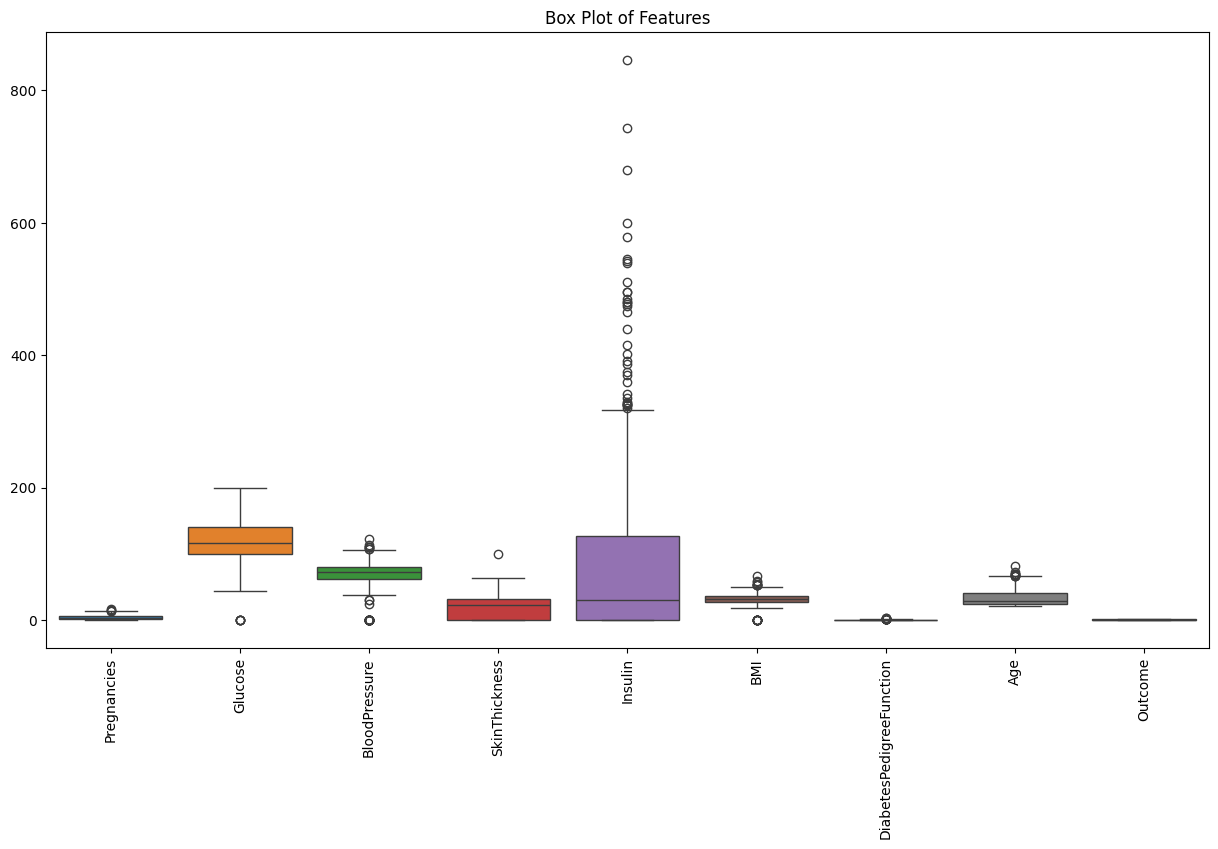

In [8]:
# Boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.title("Box Plot of Features")
plt.xticks(rotation=90)
plt.show()


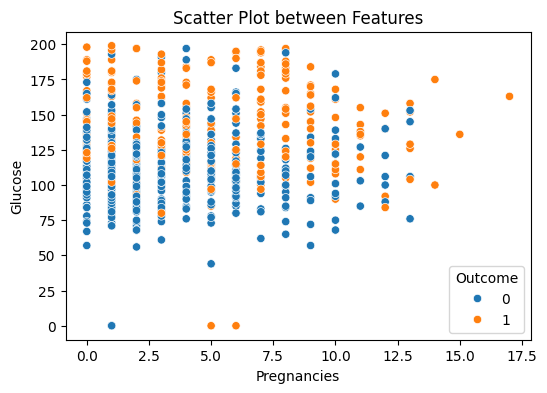

In [9]:
# Scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=df["Outcome"])
plt.title("Scatter Plot between Features")
plt.show()


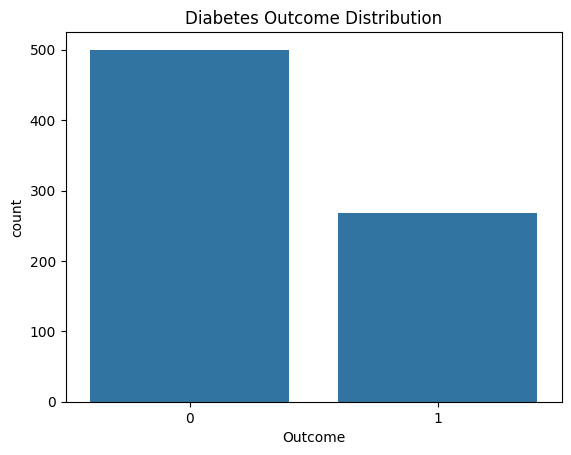

In [10]:
# barplot
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()


#### Data PreProcessing

In [11]:
# Handling Missing values
# Before filling missing values
print("Missing values BEFORE fillna():\n")
print(df.isnull().sum())

# After filling missing values
print("\nMissing values AFTER fillna():\n")
print(df.isnull().sum())

# Fill missing values with mean
df.fillna(df.mean(), inplace=True)
print(df.mean())

Missing values BEFORE fillna():

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values AFTER fillna():

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Pregnancies                   3.845052
Glucose                     120.894531
BloodPressure                69.105469
SkinThickness                20.536458
Insulin                      79.799479
BMI                          31.992578
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64


In [12]:
# Separate features and target variable
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Print feature matrix and target vector details
print("Feature Matrix (X) shape:", X.shape)
print("Target Variable (y) shape:", y.shape)

print("\nFeature Columns:\n", X.columns)
print("\nTarget Variable Sample:\n", y.head())


Feature Matrix (X) shape: (768, 8)
Target Variable (y) shape: (768,)

Feature Columns:
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target Variable Sample:
 0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print shapes of train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Print class distribution to verify stratification
print("\nClass distribution in y_train:\n", y_train.value_counts())
print("\nClass distribution in y_test:\n", y_test.value_counts())


X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)

Class distribution in y_train:
 Outcome
0    400
1    214
Name: count, dtype: int64

Class distribution in y_test:
 Outcome
0    100
1     54
Name: count, dtype: int64


#### Model Building And Training

In [23]:
# Initialize LightGBM model
lgbm = LGBMClassifier(random_state=42)
print("LightGBM model initialized.")

# Train the model
lgbm.fit(X_train, y_train)
print("LightGBM model training completed.")

# Make predictions
y_pred_lgbm = lgbm.predict(X_test)
print("LightGBM predictions generated.")

# Print sample predictions
print("\nSample predictions (rows):", y_pred_lgbm[::-1])


LightGBM model initialized.
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

In [15]:
# LightBGM Evaluation
print("LightGBM Classification Report:\n")
print(classification_report(y_test, y_pred_lgbm))


LightGBM Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



In [18]:
#XGBoost Model Prediction
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Predicted Values:")
print(y_pred_xgb)


XGBoost Predicted Values:
[1 0 0 1 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


#### Model Evaluation

In [19]:
# LightGBM Metrics
print("LightGBM Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall:", recall_score(y_test, y_pred_lgbm))
print("F1 Score:", f1_score(y_test, y_pred_lgbm))


LightGBM Performance
Accuracy: 0.7467532467532467
Precision: 0.6530612244897959
Recall: 0.5925925925925926
F1 Score: 0.6213592233009708


In [20]:
#XGBoost Metrics
print("XGBoost Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))


XGBoost Performance
Accuracy: 0.7337662337662337
Precision: 0.6226415094339622
Recall: 0.6111111111111112
F1 Score: 0.616822429906542


#### Comparative Analysis

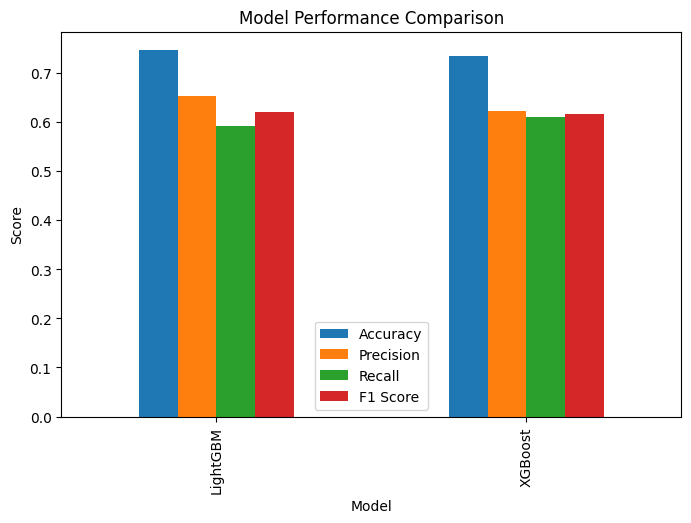

In [21]:
results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_xgb)
    ]
})

results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()


In [22]:
# HyperParameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'),
                    param_grid,
                    cv=3,
                    scoring='f1')

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


In [ ]:
# Objective:

#The goal of this project was to compare the performance of LightGBM and XGBoost models on the Diabetes dataset for predicting diabetes outcomes.

# EDA Findings:

#The dataset contains numerical medical attributes such as glucose, BMI, and age.

#Some features showed outliers, especially BMI and insulin.

#The dataset is moderately imbalanced but suitable for classification.

In [ ]:
# Model Performance:

#Both models performed well on the test dataset.

#XGBoost showed slightly better precision and F1-score.

#LightGBM trained faster and performed competitively.


In [ ]:
# Conclusion:

#XGBoost is preferred when accuracy and recall are critical.

#LightGBM is efficient for large datasets and faster training.

#Both models are effective for diabetes prediction with proper preprocessing.